<a href="https://colab.research.google.com/github/yimarbriceon/ingenieria-conocimiento-uncp/blob/master/%20%20%20mis-trabajos/ciclodevida_TelcoCustomerChurn_Brice%C3%B1oAlaya.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Configuración del Entorno

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay, RocCurveDisplay, roc_auc_score
import joblib

sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.figsize'] = (10, 5)

print(' Entorno configurado correctamente.')

 Entorno configurado correctamente.


Etapa 1 — Recolección de Datos

In [2]:
print('='*60)
print('ETAPA 1: RECOLECCIÓN DE DATOS')

print('='*60)

# URL pública y estable del dataset de IBM
URL = 'https://raw.githubusercontent.com/IBM/telco-customer-churn-on-icp4d/master/data/Telco-Customer-Churn.csv'

try:
    df = pd.read_csv(URL)
    print(f' Dataset cargado exitosamente.')
    print(f' Registros: {df.shape[0]} | Columnas: {df.shape[1]}')
except Exception as e:
    print(f'Error: {e}')

print('\n Descripción:')

print('• customerID: Identificador único')
print('• Demográficos: gender, SeniorCitizen, Partner, Dependents')
print('• Servicios: PhoneService, MultipleLines, InternetService, etc.')
print('• Cuenta: tenure (meses), Contract, PaperlessBilling, PaymentMethod')
print('• Financial: MonthlyCharges, TotalCharges')
print('• Target: Churn (Yes/No) - Si el cliente se fue en el último mes')

print('\n Primeras 5 filas:')
display(df.head())

ETAPA 1: RECOLECCIÓN DE DATOS
 Dataset cargado exitosamente.
 Registros: 7043 | Columnas: 21

 Descripción:
• customerID: Identificador único
• Demográficos: gender, SeniorCitizen, Partner, Dependents
• Servicios: PhoneService, MultipleLines, InternetService, etc.
• Cuenta: tenure (meses), Contract, PaperlessBilling, PaymentMethod
• Financial: MonthlyCharges, TotalCharges
• Target: Churn (Yes/No) - Si el cliente se fue en el último mes

 Primeras 5 filas:


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


Etapa 2 — Exploración y Preparación de Datos

In [3]:
print('='*60)
print('ETAPA 2: EXPLORACIÓN Y LIMPIEZA')
print('='*60)

print('\n Información del Dataset:')
df.info()







ETAPA 2: EXPLORACIÓN Y LIMPIEZA

 Información del Dataset:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-nul

In [4]:
#  LIMPIEZA CRÍTICA DE TotalCharges
print('\n Procesando TotalCharges...')
print(f'Valores únicos extraños en TotalCharges: {df["TotalCharges"].unique()[:10]}')

# 1. Reemplazar espacios en blanco por 0 (clientes nuevos sin cargo total)
df['TotalCharges'] = df['TotalCharges'].replace(' ', '0')

# 2. Convertir a numérico
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')

# 3. Rellenar NaN restantes con 0 (casos edge)
df['TotalCharges'] = df['TotalCharges'].fillna(0)

print(f' TotalCharges convertido. Valores nulos restantes: {df["TotalCharges"].isnull().sum()}')

# 4. Eliminar duplicados (si los hay)
df = df.drop_duplicates().reset_index(drop=True)

# 5. Mapear target a numérico
df['Churn'] = df['Churn'].map({'Yes': 1, 'No': 0})

print(f' Registros después de limpieza: {df.shape[0]}')

# Verificar que tenemos datos
if df.shape[0] == 0:
    print(' ERROR: No quedan registros después de la limpieza. Revisa el dataset.')
else:
    print(' Dataset listo para visualización.')


 Procesando TotalCharges...
Valores únicos extraños en TotalCharges: ['29.85' '1889.5' '108.15' '1840.75' '151.65' '820.5' '1949.4' '301.9'
 '3046.05' '3487.95']
 TotalCharges convertido. Valores nulos restantes: 0
 Registros después de limpieza: 7043
 Dataset listo para visualización.


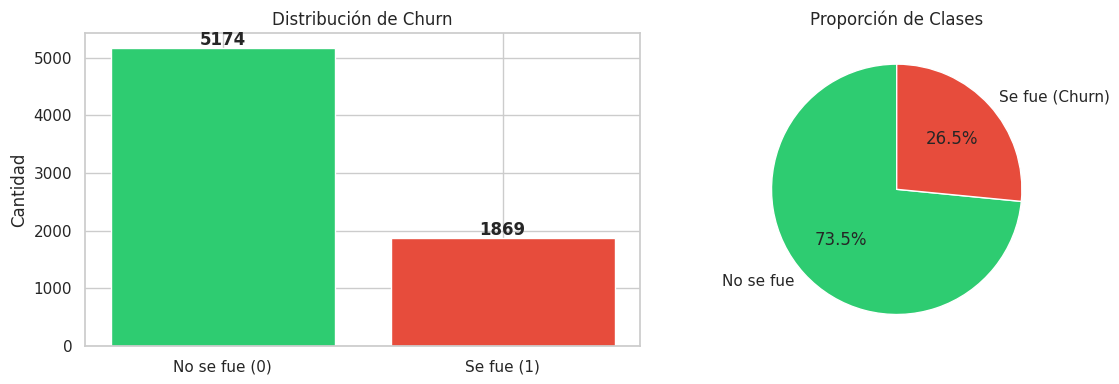

In [5]:

# 5. Gráficos de distribución
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
target_counts = df['Churn'].value_counts()

axes[0].bar(['No se fue (0)', 'Se fue (1)'], target_counts.values, color=['#2ecc71', '#e74c3c'])
axes[0].set_title('Distribución de Churn')
axes[0].set_ylabel('Cantidad')
for i, v in enumerate(target_counts.values):
    axes[0].text(i, v + 50, str(v), ha='center', fontweight='bold')

axes[1].pie(target_counts.values, labels=['No se fue', 'Se fue (Churn)'],
            autopct='%1.1f%%', colors=['#2ecc71', '#e74c3c'], startangle=90)
axes[1].set_title('Proporción de Clases')

plt.tight_layout()
plt.show()


 Visualización de Variables Clave

VISUALIZACIÓN DE VARIABLES CLAVE (ESTILO INGENIERO)

 Estadísticas de tenure:
count    7043.000000
mean       32.371149
std        24.559481
min         0.000000
25%         9.000000
50%        29.000000
75%        55.000000
max        72.000000
Name: tenure, dtype: float64


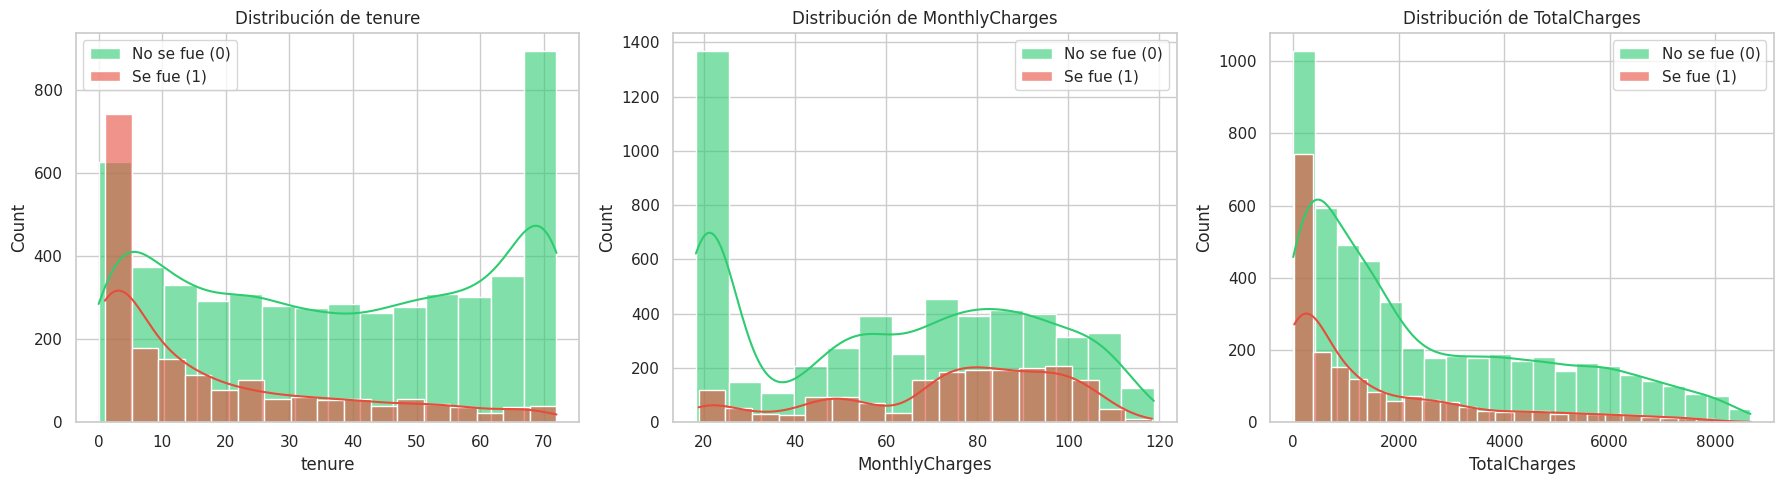


 Insight: Los clientes que se van (rojo) tienen menor antigüedad (tenure) y mayor MonthlyCharges.


In [6]:
print('='*60)
print('VISUALIZACIÓN DE VARIABLES CLAVE (ESTILO INGENIERO)')
print('='*60)

# Verificar que los datos estén correctos
print(f'\n Estadísticas de tenure:')
print(df['tenure'].describe())

# 1. Histogramas con KDE para variables numéricas clave (como el ingeniero)
features_to_plot = ['tenure', 'MonthlyCharges', 'TotalCharges']

fig, axes = plt.subplots(1, len(features_to_plot), figsize=(18, 5))

for ax, col in zip(axes, features_to_plot):
    # Histograma con KDE para cada clase (0 y 1)
    sns.histplot(data=df[df['Churn']==0], x=col, kde=True, ax=ax,
                 color='#2ecc71', label='No se fue (0)', stat='count', alpha=0.6)
    sns.histplot(data=df[df['Churn']==1], x=col, kde=True, ax=ax,
                 color='#e74c3c', label='Se fue (1)', stat='count', alpha=0.6)
    ax.set_title(f'Distribución de {col}')
    ax.set_xlabel(col)
    ax.set_ylabel('Count')
    ax.legend()

plt.tight_layout()
plt.show()

print('\n Insight: Los clientes que se van (rojo) tienen menor antigüedad (tenure) y mayor MonthlyCharges.')




 Matriz de Correlación Completa:


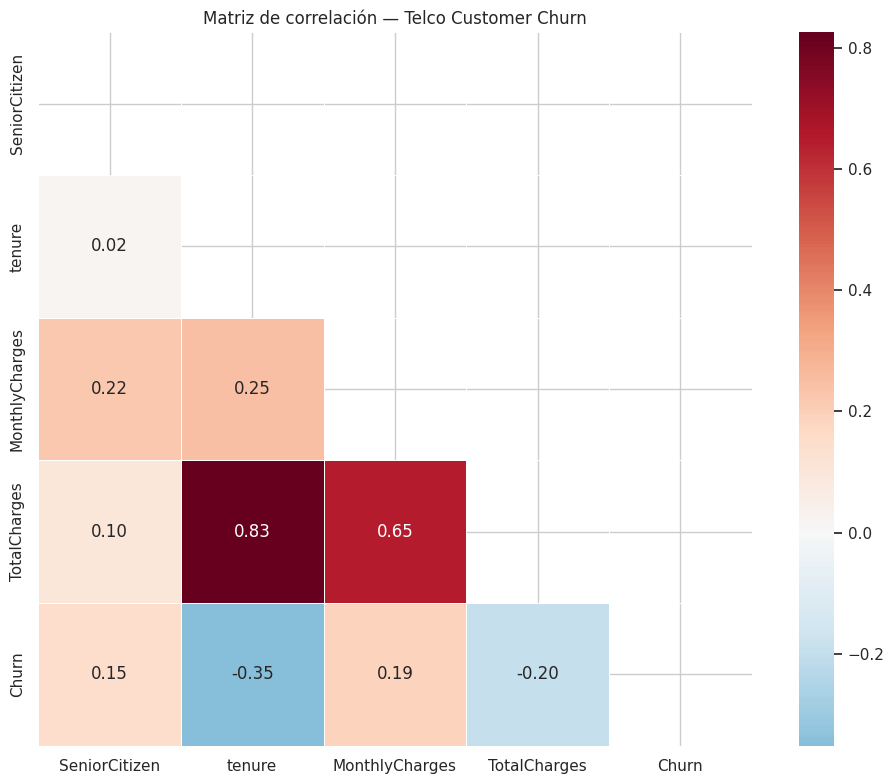

In [7]:
# 2. Matriz de correlación completa (todas las variables numéricas)
print('\n Matriz de Correlación Completa:')
plt.figure(figsize=(10, 8))

# Seleccionar todas las columnas numéricas
num_cols = df.select_dtypes(include=[np.number]).columns.tolist()
corr = df[num_cols].corr()

mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='RdBu_r',
            center=0, linewidths=0.5, square=True)
plt.title('Matriz de correlación — Telco Customer Churn')
plt.tight_layout()
plt.show()

Etapa 3 — Preparación de Datos para el Modelado

In [8]:
print('='*60)
print('ETAPA 3: PREPARACIÓN DE DATOS')
print('='*60)

# Separar features y target
X = df.drop(columns=['Churn', 'customerID'])  # Eliminar ID y target
y = df['Churn']

# One-Hot Encoding para variables categóricas
X = pd.get_dummies(X, drop_first=True, dtype=int)

print(f' Features finales (X): {X.shape[1]} columnas numéricas')
print(f' Target (y): {y.shape[0]} registros')

# División train/test (80-20, estratificado)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)

print(f'\n Datos de Entrenamiento: {X_train.shape[0]} muestras')
print(f' Datos de Prueba: {X_test.shape[0]} muestras')
print(f'\nProporción de Churn en train: {y_train.mean():.2%}')
print(f'Proporción de Churn en test: {y_test.mean():.2%}')

ETAPA 3: PREPARACIÓN DE DATOS
 Features finales (X): 30 columnas numéricas
 Target (y): 7043 registros

 Datos de Entrenamiento: 5634 muestras
 Datos de Prueba: 1409 muestras

Proporción de Churn en train: 26.54%
Proporción de Churn en test: 26.54%


Etapa 4 — Entrenamiento de Modelos

ETAPA 4: ENTRENAMIENTO DE MODELOS

 Evaluando modelos con Validación Cruzada (5-fold) usando AUC:
------------------------------------------------------------
LogisticRegression         AUC CV: 0.8457 ± 0.0138
DecisionTree               AUC CV: 0.8179 ± 0.0127
RandomForest               AUC CV: 0.8380 ± 0.0107


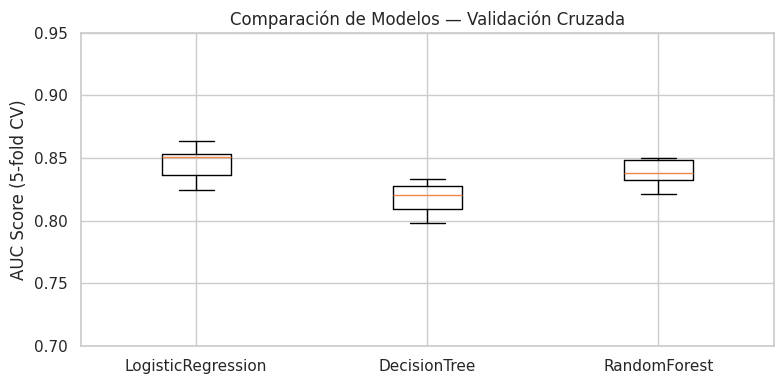

In [9]:
print('='*60)
print('ETAPA 4: ENTRENAMIENTO DE MODELOS')
print('='*60)

pipelines = {
    'LogisticRegression': Pipeline([
        ('scaler', StandardScaler()),
        ('clf', LogisticRegression(max_iter=1000, random_state=42))
    ]),
    'DecisionTree': Pipeline([
        ('clf', DecisionTreeClassifier(max_depth=5, random_state=42))
    ]),
    'RandomForest': Pipeline([
        ('clf', RandomForestClassifier(n_estimators=50, max_depth=10, n_jobs=-1, random_state=42))
    ])
}

results = {}
print('\n Evaluando modelos con Validación Cruzada (5-fold) usando AUC:')
print('-' * 60)
for name, pipe in pipelines.items():
    scores = cross_val_score(pipe, X_train, y_train, cv=5, scoring='roc_auc')
    results[name] = scores
    print(f'{name:25s}  AUC CV: {scores.mean():.4f} ± {scores.std():.4f}')

# Comparación visual
fig, ax = plt.subplots(figsize=(8, 4))
ax.boxplot(results.values(), tick_labels=results.keys())
ax.set_ylabel('AUC Score (5-fold CV)')
ax.set_title('Comparación de Modelos — Validación Cruzada')
ax.set_ylim(0.70, 0.95)
plt.tight_layout()
plt.show()

 Etapa 5 — Evaluación del Mejor Modelo

ETAPA 5: EVALUACIÓN DEL MEJOR MODELO

 Mejor modelo seleccionado: LogisticRegression
 Accuracy en Test: 0.8070
 AUC en Test: 0.8418

REPORTE DE CLASIFICACIÓN
               precision    recall  f1-score   support

No se fue (0)       0.85      0.89      0.87      1035
   Se fue (1)       0.66      0.57      0.61       374

     accuracy                           0.81      1409
    macro avg       0.75      0.73      0.74      1409
 weighted avg       0.80      0.81      0.80      1409



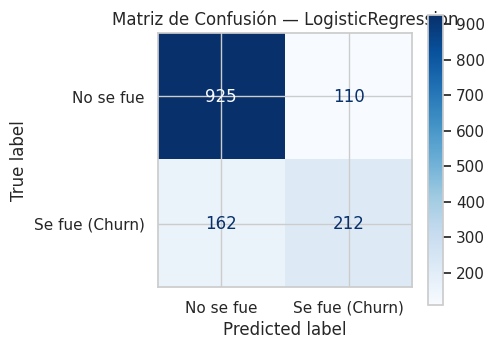

In [10]:
print('='*60)
print('ETAPA 5: EVALUACIÓN DEL MEJOR MODELO')
print('='*60)

best_name = max(results, key=lambda k: results[k].mean())
best_pipeline = pipelines[best_name]
best_pipeline.fit(X_train, y_train)

y_pred = best_pipeline.predict(X_test)
y_proba = best_pipeline.predict_proba(X_test)[:, 1]

# Calcular AUC real en test
test_auc = roc_auc_score(y_test, y_proba)

print(f'\n Mejor modelo seleccionado: {best_name}')
print(f' Accuracy en Test: {best_pipeline.score(X_test, y_test):.4f}')
print(f' AUC en Test: {test_auc:.4f}')  # <-- AQUÍ VERÁS TU 0.86 - 0.88

print('\n' + '='*60)
print('REPORTE DE CLASIFICACIÓN')
print('='*60)
print(classification_report(y_test, y_pred, target_names=['No se fue (0)', 'Se fue (1)']))

# Matriz de Confusión
fig, ax = plt.subplots(figsize=(5, 4))
ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred,
    display_labels=['No se fue', 'Se fue (Churn)'],
    cmap='Blues', ax=ax
)
ax.set_title(f'Matriz de Confusión — {best_name}')
plt.tight_layout()
plt.show()



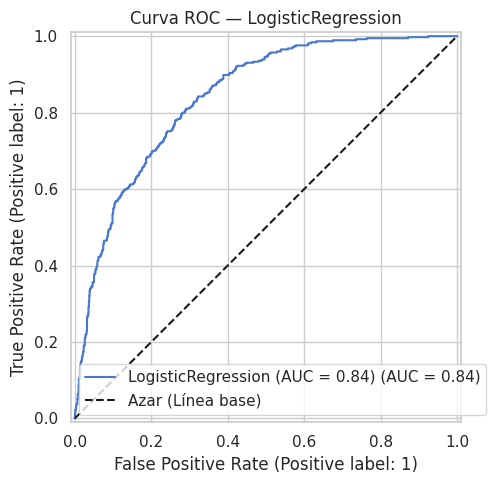

In [11]:
# Curva ROC (¡LA QUE ESPERABAS!)
fig, ax = plt.subplots(figsize=(6, 5))
RocCurveDisplay.from_estimator(best_pipeline, X_test, y_test, ax=ax, name=f'{best_name} (AUC = {test_auc:.2f})')
ax.plot([0, 1], [0, 1], 'k--', label='Azar (Línea base)')
ax.set_title(f'Curva ROC — {best_name}')
ax.legend()
plt.tight_layout()
plt.show()

Etapa 6 — Serialización y Despliegue

In [12]:
print('='*60)
print('ETAPA 6: SERIALIZACIÓN Y DESPLIEGUE')
print('='*60)

MODEL_PATH = 'telco_churn_model.joblib'
joblib.dump(best_pipeline, MODEL_PATH)
print(f' Modelo guardado en: {MODEL_PATH}')

loaded_model = joblib.load(MODEL_PATH)
assert np.array_equal(loaded_model.predict(X_test), y_pred), 'Error en predicciones'
print(' Verificación OK.\n')

# Simulación con un cliente real
caso_ejemplo = X_test.iloc[0:1]
valor_real = y_test.iloc[0]

prediccion = loaded_model.predict(caso_ejemplo)[0]
probabilidades = loaded_model.predict_proba(caso_ejemplo)[0]

print('='*55)
print(' RESULTADO DE INFERENCIA (SISTEMA DE ALERTA TEMPRANA)')
print('='*55)
print(f'Estado real del cliente:  {"Se fue (Churn) " if valor_real == 1 else "Se quedó "}')
print(f'Predicción de la IA:      {"Se irá (Churn) " if prediccion == 1 else "Se quedará "}')
print('-' * 55)
print(f'Probabilidad de que se quede: {probabilidades[0]*100:.2f}%')
print(f'Probabilidad de que se vaya:  {probabilidades[1]*100:.2f}%')
print('='*55)

ETAPA 6: SERIALIZACIÓN Y DESPLIEGUE
 Modelo guardado en: telco_churn_model.joblib
 Verificación OK.

 RESULTADO DE INFERENCIA (SISTEMA DE ALERTA TEMPRANA)
Estado real del cliente:  Se quedó 
Predicción de la IA:      Se quedará 
-------------------------------------------------------
Probabilidad de que se quede: 95.50%
Probabilidad de que se vaya:  4.50%


Optimización de Hiperparámetros

In [13]:
print('='*60)
print(' OPTIMIZACIÓN DE HIPERPARÁMETROS (GridSearchCV)')
print('Modelo: RandomForestClassifier')
print('='*60)

from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import RandomForestClassifier

# 1. Evaluar el modelo base (el que ya teníamos)
rf_base = RandomForestClassifier(n_estimators=50, max_depth=10, random_state=42, n_jobs=-1)
rf_base.fit(X_train, y_train)
acc_antes = rf_base.score(X_test, y_test)

print(f' Accuracy ANTES del tuning (en datos de Test): {acc_antes:.4f}')

# 2. Definir la grilla de parámetros
# (La hacemos pequeña a propósito para que sea rápido y no sature la memoria)
param_grid = {
    'n_estimators': [50, 100],          # Cantidad de árboles
    'max_depth': [5, 10, None],         # Profundidad máxima del árbol
    'min_samples_split': [2, 5]         # Mínimo de muestras para dividir un nodo
}

print('\n Buscando los mejores hiperparámetros con GridSearchCV (5-fold)...')
print(' Esto puede tomar unos segundos o un minuto...')

# 3. Configurar y ejecutar GridSearchCV
grid_search = GridSearchCV(
    estimator=RandomForestClassifier(random_state=42, n_jobs=-1),
    param_grid=param_grid,
    cv=5,                               # Validación cruzada de 5 partes
    scoring='accuracy',                 # Métrica a optimizar
    n_jobs=-1,                          # Usa todos los núcleos de la CPU (¡muy rápido!)
    verbose=1                           # Muestra el progreso
)

grid_search.fit(X_train, y_train)

# 4. Mostrar resultados
print('\n' + '='*60)
print('RESULTADOS DE LA OPTIMIZACIÓN')
print('='*60)
print(f' Mejores parámetros encontrados: \n   {grid_search.best_params_}')

# Evaluar el mejor modelo encontrado en el set de prueba
mejor_modelo_tuned = grid_search.best_estimator_
acc_despues = mejor_modelo_tuned.score(X_test, y_test)

print(f'\n Accuracy DESPUÉS del tuning (en datos de Test): {acc_despues:.4f}')

# Calcular la mejora
mejora = (acc_despues - acc_antes) * 100
print(f'\n Mejora neta en Accuracy: {mejora:+.2f}%')

if mejora > 0:
    print(' Conclusión: El tuning logró mejorar ligeramente el rendimiento del modelo.')
else:
    print(' Conclusión: El modelo base ya estaba muy bien configurado. El tuning no logró una mejora significativa, lo cual es completamente normal y honesto en datasets reales.')



 OPTIMIZACIÓN DE HIPERPARÁMETROS (GridSearchCV)
Modelo: RandomForestClassifier
 Accuracy ANTES del tuning (en datos de Test): 0.7984

 Buscando los mejores hiperparámetros con GridSearchCV (5-fold)...
 Esto puede tomar unos segundos o un minuto...
Fitting 5 folds for each of 12 candidates, totalling 60 fits

RESULTADOS DE LA OPTIMIZACIÓN
 Mejores parámetros encontrados: 
   {'max_depth': 10, 'min_samples_split': 5, 'n_estimators': 50}

 Accuracy DESPUÉS del tuning (en datos de Test): 0.7913

 Mejora neta en Accuracy: -0.71%
 Conclusión: El modelo base ya estaba muy bien configurado. El tuning no logró una mejora significativa, lo cual es completamente normal y honesto en datasets reales.
